In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [10]:
# Constants and data
R = 1.987  # cal/gmol*K
k_exp = np.array([0.0014, 0.0026, 0.0047, 0.0083, 0.014, 0.023, 0.038, 0.059, 0.09])
T = np.arange(300, 381, 10)
invT = 1.0 / T
y = np.log(k_exp)

In [11]:
# First strategy: first-order regression (ln(k) = A + B * (1/T))
coef = np.polyfit(invT, y, 1)

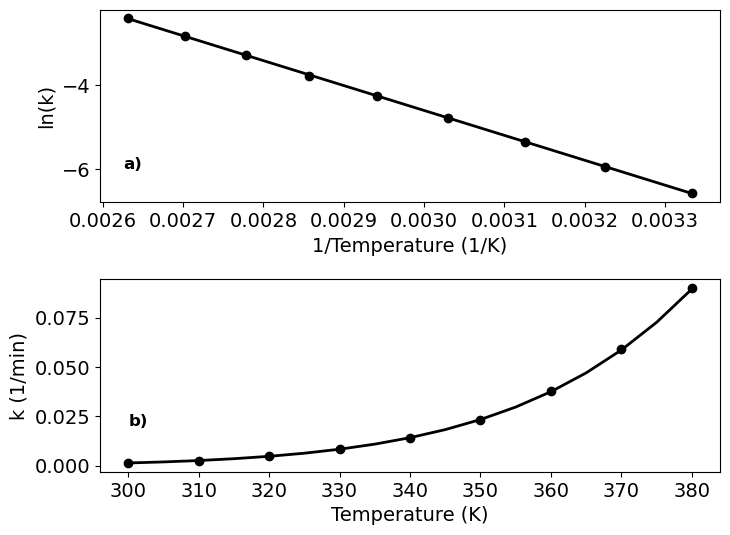

In [12]:
# Graphical comparison between model and experimental data (error)
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(invT, y, 'ko', invT, np.polyval(coef, invT), 'k', lw=2)
plt.xlabel('1/Temperature (1/K)', fontsize=14)
plt.ylabel('ln(k)', fontsize=14)
plt.text(0.002625, -6, "a)", fontsize=12, fontweight='bold')
plt.subplots_adjust(hspace=0.4)
plt.tick_params(axis='both', labelsize=14)

plt.subplot(2, 1, 2)
T1 = np.arange(300, 381, 5)
k_model = np.exp(coef[1]) * np.exp(coef[0] / T1)
plt.plot(T, k_exp, 'ko', T1, k_model, 'k', linewidth=2)
plt.xlabel('Temperature (K)', fontsize=14)
plt.ylabel('k (1/min)', fontsize=14)
plt.text(300, 0.02, "b)", fontsize=12, fontweight='bold')
plt.tick_params(axis='both', labelsize=14)

plt.show()

In [13]:
# Numerical results
A = np.exp(coef[1])
E = -coef[0] * R
print('- Linear fit (polyfit):')
print(f'A = {round(A,1)} 1/min')
print(f'E = {round(E,1)} cal/gmol')

# Sum of squared errors (SSE) between model and data
k_model = A * np.exp(coef[0] * invT)
error = np.sum((k_exp - k_model)**2)
print(f'Error (SSE) = {round(error, 9)}')

- Linear fit (polyfit):
A = 565797.7 1/min
E = 11824.2 cal/gmol
Error (SSE) = 9.03e-07


In [14]:
# Second strategy: nonlinear least-squares fit (curve_fit)
print('\n- Nonlinear fit (curve_fit):')

# Arrhenius model
def modelo(xdata, A, E_R):
    return A * np.exp(-E_R / (R * xdata))

# Initial guess and execution
initial_guess = [500000, 1e4]
params, pcov, _, mesg, _ = curve_fit(
    modelo,
    xdata=T,
    ydata=k_exp,
    p0=initial_guess,
    full_output=True
)
print("Convergence message:", mesg)


- Nonlinear fit (curve_fit):
Convergence message: Both actual and predicted relative reductions in the sum of squares
  are at most 0.000000


In [15]:
# SSE for the nonlinear fit
model_predictions = modelo(T, *params)
sse = np.sum((k_exp - model_predictions)**2)

print(f'A = {round(params[0],1)} 1/min')
print(f'E = {round(params[1],1)} cal/gmol')
print("Error (SSE) =", round(sse, 9))

A = 615364.7 1/min
E = 11882.1 cal/gmol
Error (SSE) = 3.65e-07
